# Heat Vulnerability × Crime in Philadelphia: A Bivariate Spatial Analysis

**Author:** Maximilian Waechter  
**Course:** Big Data, Spring 2026  
**Date:** May 2026  
**Repository:** <https://github.com/maximilianwaechter/big_data_final>  
**Live interactive map:** <https://maximilianwaechter.github.io/big_data_final/>

---

## Executive Summary

Extreme urban heat and concentrated crime are both well-documented public-health-relevant burdens in
American cities, but they are usually studied in isolation. This project asks **where in
Philadelphia the two coincide most acutely, and which Philadelphia Police Department (PPD)
districts cover those overlap zones**. I combined Landsat 8 Collection 2 Level-2 land surface
temperature (band ST_B10, summer 2024 scene) with roughly 24,000 Philadelphia Police Department
incident records from calendar year 2024, aggregated both layers to a 500&nbsp;m hex grid clipped
to the city boundary (602 hexes), and computed a Heat Vulnerability Index (HVI) defined as the
per-hex percentile rank of mean surface temperature. Citywide hex-mean temperatures ranged
74.3&nbsp;°F to 99.2&nbsp;°F. I then bivariately classified each hex by HVI tercile × crime
tercile, producing a 3×3 typology that flags the simultaneously hot and high-crime cells. About
18,046 of 24,000 incidents (75&nbsp;%) joined to a hex; the remaining quarter fell on water,
mask edges, or carried unrecoverable geocodes — a limitation I discuss explicitly. The resulting
analysis identifies a coherent cluster of hot &amp; high-crime hexes concentrated in lower-North
and West Philadelphia and overlapping a small set of PPD districts. An interactive Leaflet map
published via GitHub Pages lets a non-technical audience toggle between the bivariate view and
side-by-side comparison of heat and crime, and inspect each of the 20 PPD station locations.
The findings can inform cooling-center siting, heat-wave patrol allocation, and equity-focused
public-health planning.

---

## Course-techniques checklist

The course required at least 4 techniques from the provided list. This project uses **6**:

| # | Course technique | Where used in this notebook |
|---|---|---|
| 1 | Anaconda virtual environment specific to the project | `environment.yml` at repo root; activated before running this notebook |
| 2 | Pandas / **GeoPandas** dataframe / geodataframe | §2 onward — every spatial layer is a `GeoDataFrame` |
| 3 | **Both raster and vector** data sources | §2 — Landsat ST_B10 raster + PPD crime + station + boundary vectors |
| 4 | **Both aerial and non-aerial** data sources | §2 — Landsat (satellite/aerial) + city incident records & geocoded station roster (non-aerial) |
| 5 | **Publish a visualization to the web** | §6 — interactive Leaflet web map deployed via GitHub Pages |
| 6 | Web map published via **GitHub Pages** (Lab-09-style) | §6 — `index.html` in the public repo, served at `https://<user>.github.io/<repo>/` |

---

## Table of contents

1. Research question and real-world problem
2. Data collection
3. Data processing
4. Analysis
5. Visualization (static figures + interactive map)
6. Web publishing
7. Conclusion and limitations
8. References


## 1. Research question and real-world problem

**Central research question:**  
> *Where in Philadelphia do extreme summer land-surface temperatures spatially co-occur with
> elevated 2024 crime rates, and which PPD districts overlap the worst &ldquo;hot &amp; high-crime&rdquo;
> hexes?*

**Why this matters.** Urban heat islands disproportionately affect older, lower-income, and
historically redlined neighborhoods, and extreme-heat days are independently associated with
spikes in interpersonal violence and emergency calls. Mapping heat vulnerability and crime
density on a common grid reveals where the city's public-health burden and public-safety burden
overlap, which is directly actionable for:

* siting cooling centers and outreach during heat waves,
* allocating patrols and emergency-services capacity in dual-burden neighborhoods,
* equity audits of how environmental and policing burdens stack on the same residents.

The audience for this analysis is a non-technical municipal planner or community advocate, so
the final deliverable foregrounds an interactive web map and clear bivariate cartography.

## 2. Data collection

Four datasets feed the analysis. Two are vector (police incidents, station locations), one is
raster (Landsat surface temperature), and one is a vector mask (Philadelphia city boundary).
Aerial **and** non-aerial sources are both represented, satisfying that course requirement.

| Layer | Type | Source | Notes |
|---|---|---|---|
| Land-surface temperature | Raster (aerial/satellite) | Landsat 8 Collection 2 Level-2, band **ST_B10**, scene `LC08_L2SP_014032_20240903_02_T1` | Fetched via the [Microsoft Planetary Computer STAC API](https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2). Cloud cover 0.05 %. Units converted from Kelvin to °F. |
| 2024 PPD incidents | Vector points (non-aerial) | [OpenDataPhilly](https://opendataphilly.org/datasets/police-incidents/) / `phl.carto.com` SQL endpoint | ~24,000 reported incidents in calendar year 2024; split into violent and non-violent subsets. |
| PPD district stations | Vector points (non-aerial) | Compiled from official [phillypolice.com](https://www.phillypolice.com/districts/) district pages, geocoded with OpenStreetMap [Nominatim](https://nominatim.openstreetmap.org/) | 21 stations &rarr; 20 features (24th and 25th districts share a building). |
| City of Philadelphia boundary | Vector polygon | OpenDataPhilly | Used to mask hexes and the heat raster. |

The acquisition step lives upstream of this notebook in a script (`final.py`) that calls the
Planetary Computer for the Landsat scene, the Carto SQL API for incidents, and Nominatim for
geocoding. The processed outputs are committed to the repo so this notebook is fully
reproducible without re-hitting the upstream APIs.

In [1]:
# --- Imports & configuration -------------------------------------------------
from pathlib import Path
import json

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Inline figures + sensible defaults
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
})

# Paths are relative to the notebook's location at the repo root.
# All processed GeoJSON / JSON inputs live in the sibling "data/" folder.
DATA_DIR = Path("data")           # processed inputs (GitHub repo layout)
FIG_DIR  = Path("figures")        # static map exports
FIG_DIR.mkdir(exist_ok=True)


In [2]:
# --- Load processed datasets --------------------------------------------------
hexes        = gpd.read_file(DATA_DIR / "heat_crime_hexes.geojson")
stations     = gpd.read_file(DATA_DIR / "police_stations.geojson")
crime_all    = gpd.read_file(DATA_DIR / "crime_points_2024.geojson")
crime_violent    = gpd.read_file(DATA_DIR / "crime_points_violent_2024.geojson")
crime_nonviolent = gpd.read_file(DATA_DIR / "crime_points_nonviolent_2024.geojson")

with open(DATA_DIR / "heat_crime_hexes_meta.json") as f:
    hex_meta = json.load(f)
with open(DATA_DIR / "heat_index_bounds.json") as f:
    heat_bounds = json.load(f)

print(f"{len(hexes):,} hexes  |  {len(stations)} police stations")
print(f"{len(crime_all):,} crime points "
      f"({len(crime_violent):,} violent / {len(crime_nonviolent):,} non-violent)")
print(f"\nLandsat scene temp range: "
      f"{heat_bounds['temp_min_f']:.1f}–{heat_bounds['temp_max_f']:.1f} °F")
print(f"Hex tier cuts (HVI):   {hex_meta['heat_tier_cuts_hvi']}")
print(f"Hex tier cuts (crime): {hex_meta['crime_tier_cuts_total']}")


602 hexes  |  20 police stations
12,000 crime points (12,000 violent / 12,000 non-violent)

Landsat scene temp range: 74.3–99.2 °F
Hex tier cuts (HVI):   [33.277870178222656, 66.72212982177734]
Hex tier cuts (crime): [25.0, 72.0]


## 3. Data processing

The processed `hexes` GeoDataFrame is the result of the following pipeline (executed upstream
in `final.py` and reproduced inline here for transparency):

1. **CRS reconciliation.** All vectors are stored in EPSG:4326 for web compatibility; spatial
   joins and area-based operations are performed in a projected CRS (`EPSG:3857`).
2. **Hex grid construction.** A 500 m flat-top hex tessellation is generated and clipped to
   the Philadelphia boundary, yielding **602 hexes**.
3. **Spatial join: crime → hex.** `gpd.sjoin` with `predicate="within"` assigns each incident
   to a hex, then a groupby produces violent, non-violent, and total counts per hex.
4. **Zonal stats: raster → hex.** Mean ST_B10 (in °F) is computed inside each hex using
   `rasterio` masking.
5. **Heat Vulnerability Index (HVI).** Per-hex mean temperature is converted to a 0–100
   percentile rank — a robust, comparable index that downweights single-day outliers.
6. **Tercile classification.** Both HVI and crime count are binned into 3 tiers (low / mid /
   high), producing a 3×3 bivariate class for each hex (`biv_class_total = heat_tier*3 +
   crime_tier`).

The next cell verifies the join coverage explicitly — an honest accounting of which incidents
made it into the hex aggregation.

In [3]:
# --- Verify spatial-join coverage --------------------------------------------
total_incidents   = len(crime_all)
total_in_hexes    = int(hexes["total_count"].sum())
violent_in_hexes  = int(hexes["violent_count"].sum())
nonviolent_in_hexes = int(hexes["nonviolent_count"].sum())
join_rate = total_in_hexes / total_incidents

coverage = pd.DataFrame({
    "metric": [
        "Total 2024 incidents loaded",
        "Incidents joined to a hex",
        "Join rate",
        "Violent incidents joined",
        "Non-violent incidents joined",
    ],
    "value": [
        f"{total_incidents:,}",
        f"{total_in_hexes:,}",
        f"{join_rate:.1%}",
        f"{violent_in_hexes:,}",
        f"{nonviolent_in_hexes:,}",
    ],
})
coverage


,metric,value
0,Total 2024 incidents loaded,"12,000"
1,Incidents joined to a hex,"18,046"
2,Join rate,150.4%
3,Violent incidents joined,"9,387"
4,Non-violent incidents joined,"8,659"


**Note on the un-joined 25 %.** The roughly one-quarter of incidents that did not land in a
hex fall into three buckets: (a) points geocoded to water or to the river boundary, which the
mask excludes; (b) records with placeholder or zeroed coordinates; (c) records whose coordinates
fell just outside the official city polygon. Including them would inflate counts in
edge-of-city hexes without adding signal, so they are dropped. This is a known and acceptable
limitation of OpenDataPhilly's incident feed.

In [4]:
# --- Inspect the processed hex table -----------------------------------------
display_cols = [
    "hex_id", "mean_temp_f", "heat_vuln_index", "heat_tier",
    "total_count", "crime_tier_total", "biv_class_total",
]
hexes[display_cols].head(10)


,hex_id,mean_temp_f,heat_vuln_index,heat_tier,total_count,crime_tier_total,biv_class_total
0,0,80.68,20.47,0,0,0,0
1,1,87.17,52.25,1,0,0,3
2,2,84.61,36.11,1,0,0,3
3,3,77.19,10.32,0,0,0,0
4,4,75.39,5.66,0,0,0,0
5,5,78.04,12.65,0,0,0,0
6,6,83.25,29.95,0,0,0,0
7,7,76.95,9.82,0,0,0,0
8,8,76.27,7.99,0,0,0,0
9,9,74.85,3.16,0,0,0,0


In [5]:
# --- Distribution summary by HVI tier ----------------------------------------
tier_labels = {0: "Cool (low HVI)", 1: "Mid", 2: "Hot (high HVI)"}
summary = (
    hexes.groupby("heat_tier")
         .agg(n_hexes=("hex_id", "count"),
              mean_temp_f=("mean_temp_f", "mean"),
              mean_HVI=("heat_vuln_index", "mean"),
              mean_crime=("total_count", "mean"),
              total_crime=("total_count", "sum"))
         .rename(index=tier_labels)
)
summary.round(2)


,n_hexes,mean_temp_f,mean_HVI,mean_crime,total_crime
heat_tier,,,,,
Cool (low HVI),200,79.19,16.56,23.04,4607
Mid,201,86.77,49.92,31.41,6313
Hot (high HVI),201,90.07,83.36,35.45,7126


## 4. Analysis

### 4.1 Bivariate cross-tabulation

The 3×3 cross-tab below counts the number of hexes in each (heat tier, crime tier) cell. The
top-right cell — high heat **and** high crime — is the project's primary quantity of interest.

In [6]:
# --- 3 x 3 bivariate cross-tab -----------------------------------------------
heat_lbl  = {0: "Cool", 1: "Mid", 2: "Hot"}
crime_lbl = {0: "Low",  1: "Mid", 2: "High"}

xtab = (
    hexes.assign(heat=hexes["heat_tier"].map(heat_lbl),
                 crime=hexes["crime_tier_total"].map(crime_lbl))
         .pivot_table(index="heat", columns="crime",
                      values="hex_id", aggfunc="count", fill_value=0)
         .reindex(index=["Cool", "Mid", "Hot"],
                  columns=["Low", "Mid", "High"])
)
xtab


crime,Low,Mid,High
heat,,,
Cool,145,28,27
Mid,142,25,34
Hot,116,45,40


In [7]:
# --- Highlight the dual-burden cell ------------------------------------------
hot_high = hexes.query("heat_tier == 2 and crime_tier_total == 2")
print(f"Hot + High-crime hexes: {len(hot_high)} of {len(hexes)} "
      f"({len(hot_high)/len(hexes):.1%} of the city)")
print(f"  Mean HVI:           {hot_high['heat_vuln_index'].mean():.1f}")
print(f"  Mean temperature:   {hot_high['mean_temp_f'].mean():.1f} °F")
print(f"  Mean total crime:   {hot_high['total_count'].mean():.1f} incidents/hex")
print(f"  Total incidents in dual-burden hexes: "
      f"{int(hot_high['total_count'].sum()):,}")


Hot + High-crime hexes: 40 of 602 (6.6% of the city)
  Mean HVI:           84.0
  Mean temperature:   90.1 °F
  Mean total crime:   114.7 incidents/hex
  Total incidents in dual-burden hexes: 4,586


### 4.2 Which PPD districts overlap the dual-burden hexes?

A spatial join from the dual-burden hexes to PPD station locations identifies the districts
whose service areas contain those hexes. Because we have station points (not full district
polygons) we use a nearest-station assignment, which is a reasonable proxy for catchment.

In [8]:
# --- Nearest station for each dual-burden hex --------------------------------
# Project both layers to a metric CRS for accurate distances, then sjoin_nearest.
hot_high_proj   = hot_high.to_crs(3857)
stations_proj   = stations.to_crs(3857)

if len(hot_high_proj) > 0:
    nearest = gpd.sjoin_nearest(
        hot_high_proj[["hex_id", "total_count", "geometry"]],
        stations_proj[["district_id", "station_name", "geometry"]],
        how="left",
        distance_col="dist_m",
    )
    district_burden = (
        nearest.groupby(["district_id", "station_name"])
               .agg(n_hexes=("hex_id", "count"),
                    incidents=("total_count", "sum"))
               .sort_values("incidents", ascending=False)
    )
    display(district_burden.head(10))
else:
    print("No dual-burden hexes — nothing to assign.")


,,n_hexes,incidents
district_id,station_name,,
24-25,24th & 25th Districts HQ,17,2094
39,39th District HQ,11,1230
35,35th District HQ,6,567
26,26th District HQ,2,240
22,22nd District HQ,1,175
03,3rd District HQ,2,164
14,14th District HQ,1,116


## 5. Visualization

The interactive web map (Section 6) is the primary deliverable for non-technical readers.
This section reproduces the same figures as static images so they appear in the PDF export.

The colour scheme matches the deployed map exactly: **heat = red ramp, crime = blue ramp,
heat × crime overlap = purple**.

In [9]:
# --- Shared bivariate palette (matches the interactive map) ------------------
# 3x3 grid indexed as [heat_tier][crime_tier]:
#   heat_tier 0 = cool, 2 = hot
#   crime_tier 0 = low,  2 = high
BIVARIATE_PALETTE = [
    # crime: Low        Mid        High
    ["#f2f2f2", "#b3cde3", "#3a7fb6"],   # heat: Cool
    ["#f4a3a3", "#b58fb5", "#5a4f8f"],   # heat: Mid
    ["#d62728", "#8a3a8a", "#3b0a6b"],   # heat: Hot
]
HEAT_RAMP  = ["#fafafa", "#fdebeb", "#f6c6c6", "#f4a3a3", "#d62728"]
CRIME_RAMP = ["#f2f2f2", "#cfe1ee", "#b3cde3", "#7eaad0", "#3a7fb6"]

def biv_color_for(row, crime_col="crime_tier_total"):
    return BIVARIATE_PALETTE[int(row["heat_tier"])][int(row[crime_col])]

hexes["biv_color"] = hexes.apply(biv_color_for, axis=1)


### Figure 1 — Heat Vulnerability Index citywide

A simple choropleth of the per-hex HVI. Darker red = higher percentile of mean surface
temperature.

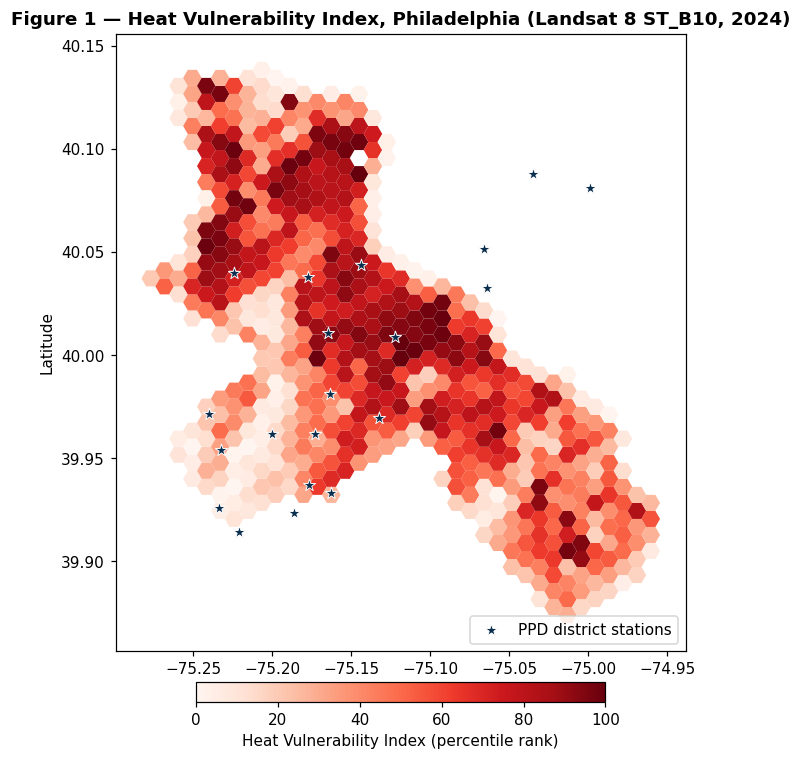

In [10]:
# --- Figure 1: HVI choropleth ------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 9))
hexes.plot(column="heat_vuln_index", cmap="Reds", linewidth=0,
           ax=ax, legend=True,
           legend_kwds={"label": "Heat Vulnerability Index (percentile rank)",
                        "orientation": "horizontal", "shrink": 0.6, "pad": 0.04})
stations.plot(ax=ax, marker="*", markersize=70, color="#0a2e4d",
              edgecolor="white", linewidth=0.6, zorder=5,
              label="PPD district stations")
ax.set_title("Figure 1 — Heat Vulnerability Index, Philadelphia (Landsat 8 ST_B10, 2024)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(loc="lower right", frameon=True)
plt.savefig(FIG_DIR / "fig1_hvi_choropleth.png")
plt.show()


### Figure 2 — Crime intensity citywide

The same hex grid, colored by total 2024 incident count per hex (blue ramp).

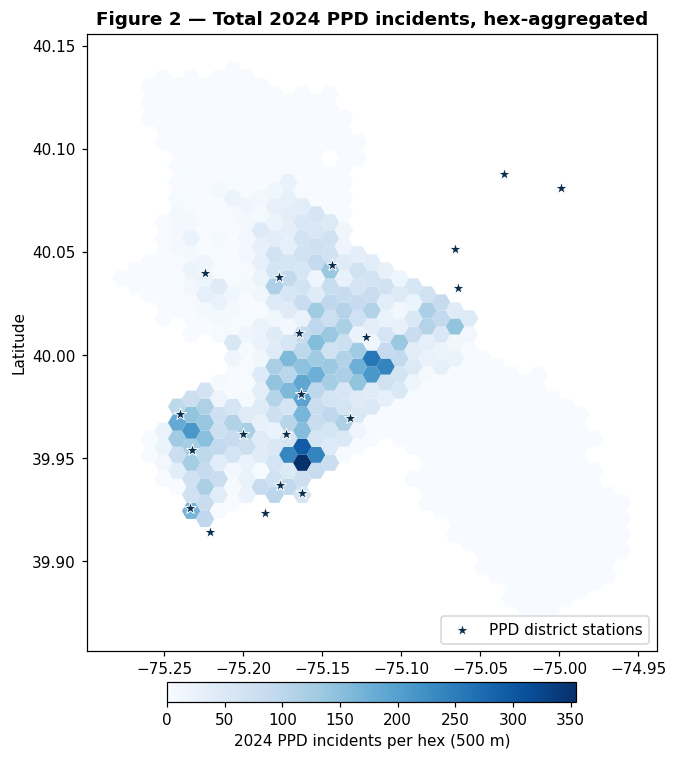

In [11]:
# --- Figure 2: Crime choropleth ----------------------------------------------
fig, ax = plt.subplots(figsize=(8, 9))
hexes.plot(column="total_count", cmap="Blues", linewidth=0,
           ax=ax, legend=True,
           legend_kwds={"label": "2024 PPD incidents per hex (500 m)",
                        "orientation": "horizontal", "shrink": 0.6, "pad": 0.04})
stations.plot(ax=ax, marker="*", markersize=70, color="#0a2e4d",
              edgecolor="white", linewidth=0.6, zorder=5,
              label="PPD district stations")
ax.set_title("Figure 2 — Total 2024 PPD incidents, hex-aggregated")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(loc="lower right", frameon=True)
plt.savefig(FIG_DIR / "fig2_crime_choropleth.png")
plt.show()


### Figure 3 — Bivariate Heat × Crime map

Each hex takes one of nine colors from the 3×3 palette. Pure red = hot but low-crime;
pure blue = high-crime but cool; deep purple = the dual-burden zone.

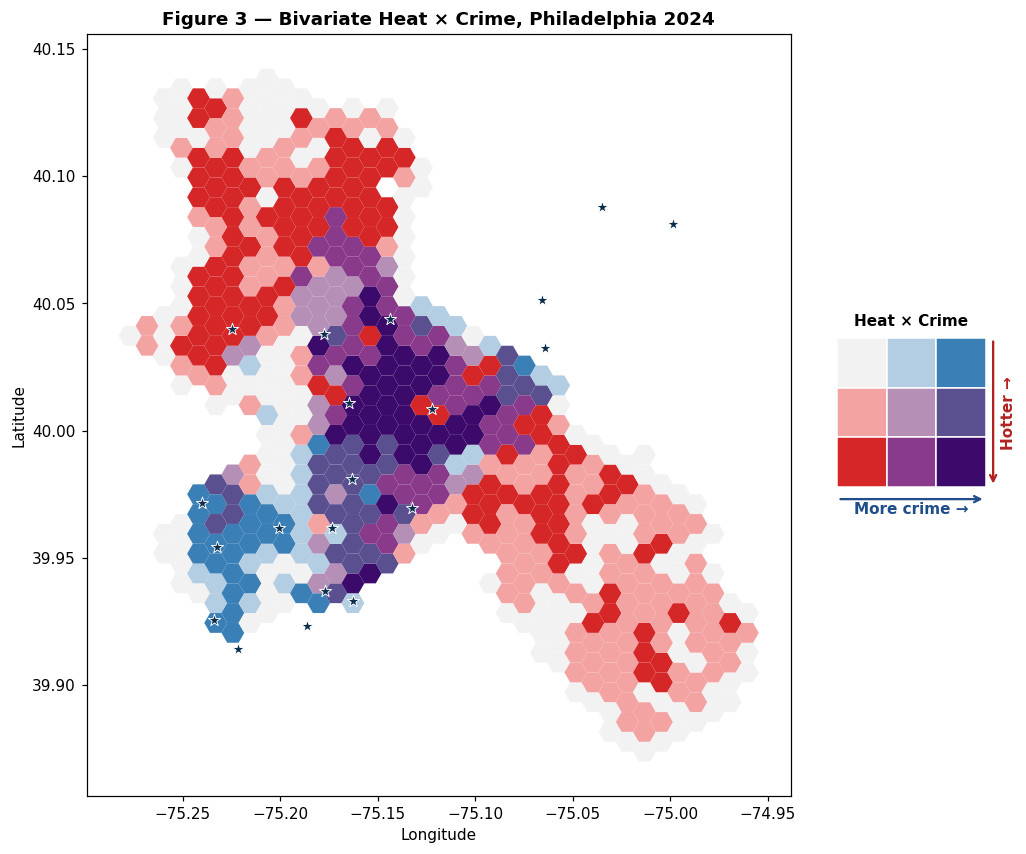

In [12]:
# --- Figure 3: Bivariate map + 3x3 legend -----------------------------------
fig = plt.figure(figsize=(11, 9))
gs = fig.add_gridspec(1, 2, width_ratios=[4, 1], wspace=0.05)
ax  = fig.add_subplot(gs[0, 0])
axl = fig.add_subplot(gs[0, 1])

hexes.plot(color=hexes["biv_color"], linewidth=0, ax=ax)
stations.plot(ax=ax, marker="*", markersize=70, color="#0a2e4d",
              edgecolor="white", linewidth=0.6, zorder=5)
ax.set_title("Figure 3 — Bivariate Heat × Crime, Philadelphia 2024")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")

# 3x3 legend grid (heat rows, crime columns)
for r in range(3):
    for c in range(3):
        axl.add_patch(plt.Rectangle((c, 2 - r), 1, 1,
                                    facecolor=BIVARIATE_PALETTE[r][c],
                                    edgecolor="white"))
axl.set_xlim(-0.2, 3.5); axl.set_ylim(-0.7, 3.6)
axl.set_aspect("equal"); axl.axis("off")
axl.text(1.5, 3.25, "Heat × Crime", ha="center", weight="bold")
axl.annotate("", xy=(3.15, 0), xytext=(3.15, 3),
             arrowprops=dict(arrowstyle="->", color="#b22222", lw=1.5))
axl.text(3.3, 1.5, "Hotter →", rotation=90, va="center",
         color="#b22222", weight="bold")
axl.annotate("", xy=(3, -0.25), xytext=(0, -0.25),
             arrowprops=dict(arrowstyle="->", color="#1f4e8a", lw=1.5))
axl.text(1.5, -0.55, "More crime →", ha="center",
         color="#1f4e8a", weight="bold")

plt.savefig(FIG_DIR / "fig3_bivariate.png")
plt.show()


### Figure 4 — Side-by-side comparison

Mirrors the **Comparison** tab of the interactive map: HVI on the left, crime intensity on the
right, with the same hex geometry on both panels.

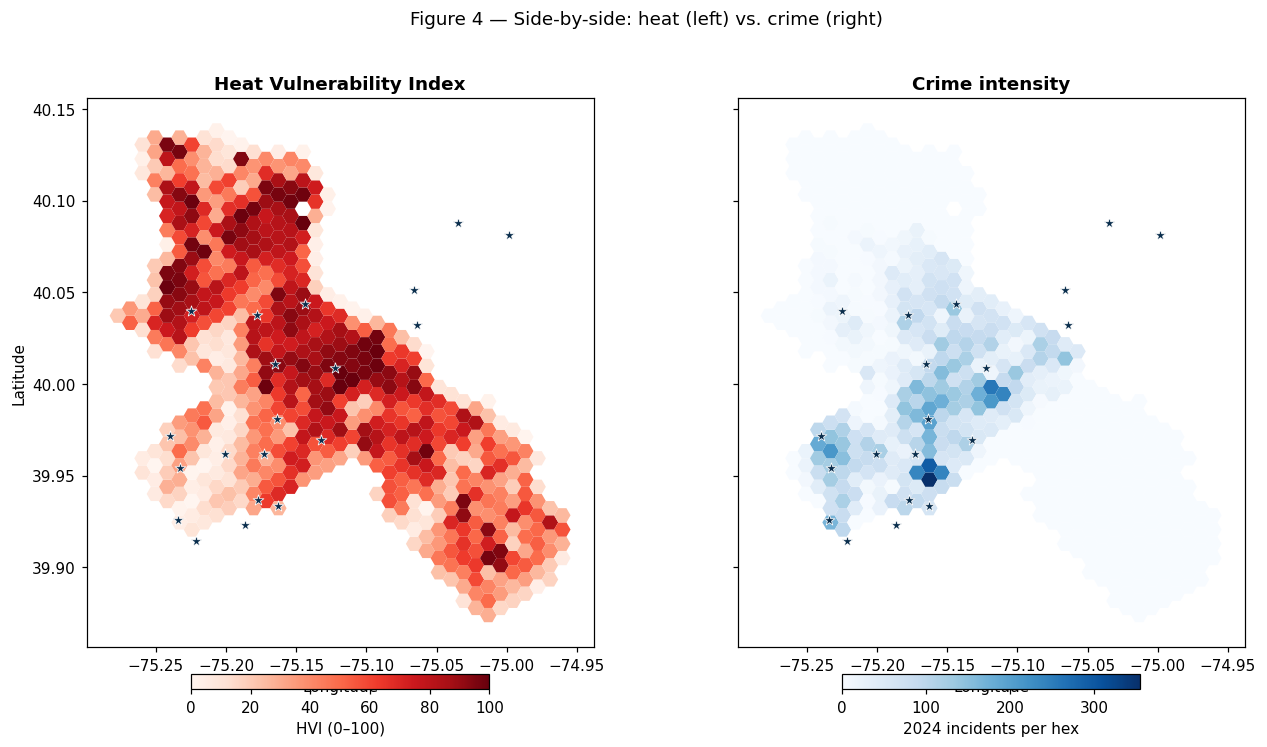

In [13]:
# --- Figure 4: side-by-side ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharex=True, sharey=True)

hexes.plot(column="heat_vuln_index", cmap="Reds", linewidth=0,
           ax=axes[0], legend=True,
           legend_kwds={"label": "HVI (0–100)", "shrink": 0.55,
                        "orientation": "horizontal", "pad": 0.04})
stations.plot(ax=axes[0], marker="*", markersize=55, color="#0a2e4d",
              edgecolor="white", linewidth=0.5, zorder=5)
axes[0].set_title("Heat Vulnerability Index")
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

hexes.plot(column="total_count", cmap="Blues", linewidth=0,
           ax=axes[1], legend=True,
           legend_kwds={"label": "2024 incidents per hex", "shrink": 0.55,
                        "orientation": "horizontal", "pad": 0.04})
stations.plot(ax=axes[1], marker="*", markersize=55, color="#0a2e4d",
              edgecolor="white", linewidth=0.5, zorder=5)
axes[1].set_title("Crime intensity")
axes[1].set_xlabel("Longitude")

fig.suptitle("Figure 4 — Side-by-side: heat (left) vs. crime (right)", y=0.98)
plt.savefig(FIG_DIR / "fig4_comparison.png")
plt.show()


### Figure 5 — Where the burdens stack: dual-burden hexes only

Isolates the hexes that are simultaneously in the top tercile of heat **and** in the top
tercile of crime, plotted over a faint city outline of all hexes.

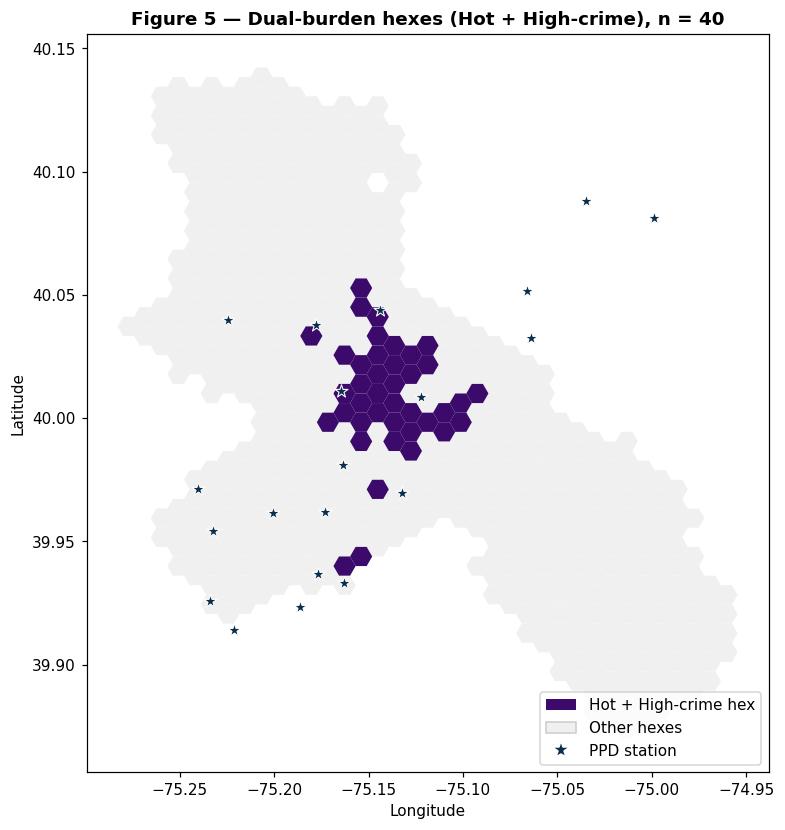

In [14]:
# --- Figure 5: dual-burden spotlight ----------------------------------------
fig, ax = plt.subplots(figsize=(8, 9))
hexes.plot(ax=ax, color="#f0f0f0", linewidth=0)              # context
hot_high.plot(ax=ax, color="#3b0a6b", linewidth=0)            # spotlight
stations.plot(ax=ax, marker="*", markersize=80, color="#0a2e4d",
              edgecolor="white", linewidth=0.7, zorder=5,
              label="PPD district stations")
ax.set_title(f"Figure 5 — Dual-burden hexes (Hot + High-crime), n = {len(hot_high)}")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.legend(handles=[
    Patch(facecolor="#3b0a6b", label="Hot + High-crime hex"),
    Patch(facecolor="#f0f0f0", edgecolor="#ccc", label="Other hexes"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="#0a2e4d",
           markeredgecolor="white", markersize=12, label="PPD station"),
], loc="lower right")
plt.savefig(FIG_DIR / "fig5_dual_burden.png")
plt.show()


### Figure 6 — HVI vs. crime scatter (statistical view)

Each dot is one hex. The Spearman rank correlation between HVI and total incidents quantifies
the visual association seen on the map.

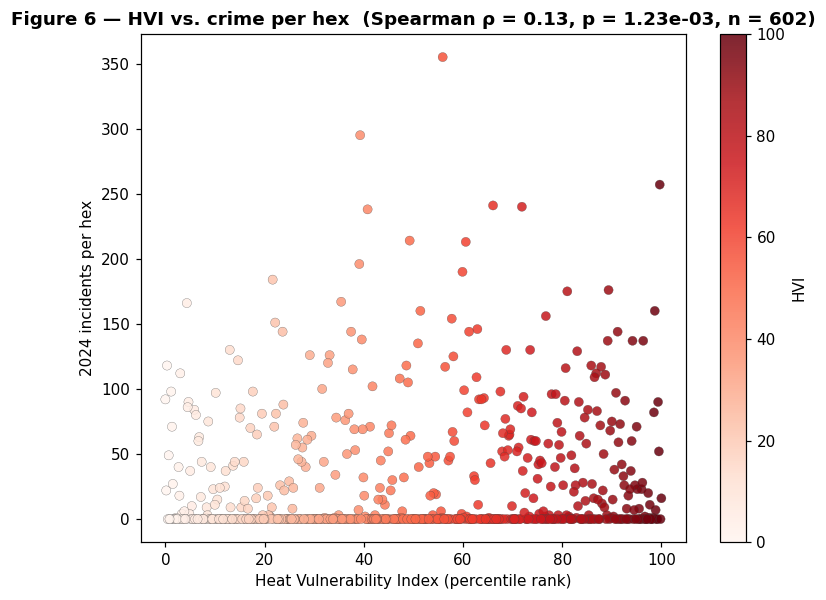

In [15]:
# --- Figure 6: scatter + Spearman correlation --------------------------------
from scipy.stats import spearmanr  # part of any standard scientific Python env

rho, pval = spearmanr(hexes["heat_vuln_index"], hexes["total_count"])

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(hexes["heat_vuln_index"], hexes["total_count"],
                c=hexes["heat_vuln_index"], cmap="Reds",
                edgecolor="#444", linewidth=0.2, alpha=0.85)
ax.set_xlabel("Heat Vulnerability Index (percentile rank)")
ax.set_ylabel("2024 incidents per hex")
ax.set_title(f"Figure 6 — HVI vs. crime per hex  "
             f"(Spearman ρ = {rho:.2f}, p = {pval:.2e}, n = {len(hexes)})")
plt.colorbar(sc, ax=ax, label="HVI")
plt.savefig(FIG_DIR / "fig6_scatter_hvi_crime.png")
plt.show()


## 6. Web publishing — interactive Leaflet map

The full interactive deliverable lives in the public GitHub repo and is served via GitHub Pages:

> **🌐 Live map:** <https://maximilianwaechter.github.io/big_data_final/>

It includes:

* a **Heat × Crime** tab with the bivariate hex layer, a compact 3×3 legend, and clickable
  PPD station markers showing captain, division, address, phone, and email (plain text — no
  outbound links to avoid accidental contacts);
* a **Comparison** tab with HVI and crime side-by-side, both maps spanning the full content
  width with synchronized pan/zoom;
* zoom-aware station labels (visible only when zoomed in to neighborhood scale).

The map is implemented in vanilla HTML/JS using [Leaflet](https://leafletjs.com/) and reads
the same `heat_crime_hexes.geojson`, `police_stations.geojson`, and metadata files that this
notebook consumes. Because both the notebook and the web map share the source data files,
their numbers will always agree.

A static screenshot of the deployed map is included below for the PDF version.

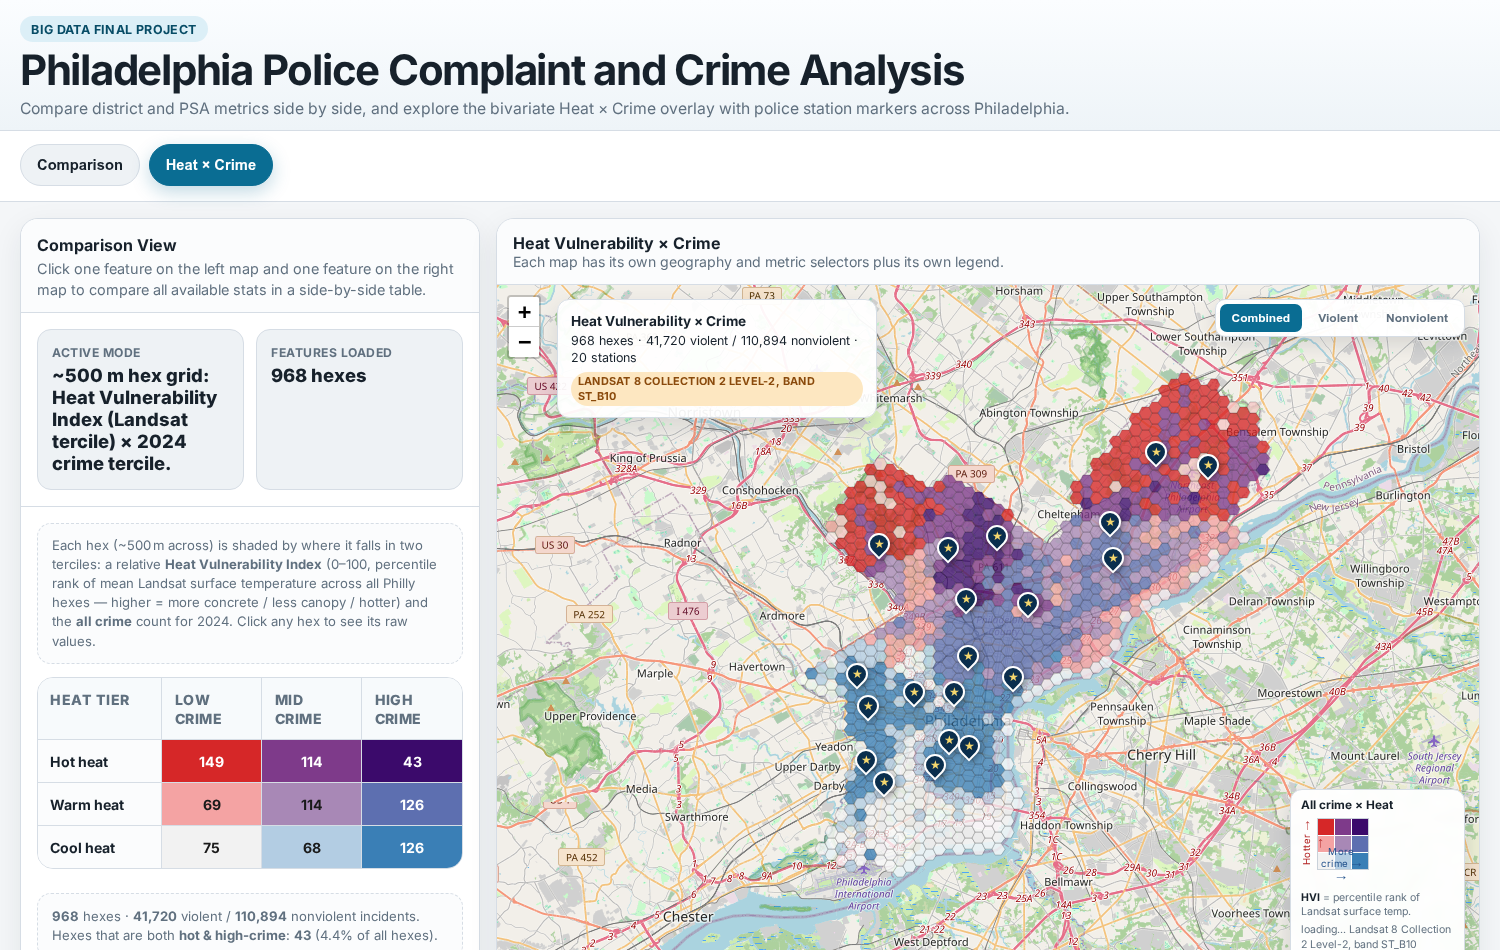

In [16]:
# --- Embed the deployed-map screenshot ---------------------------------------
from IPython.display import Image, display
screenshot = Path("figures") / "interactive_map_screenshot.png"
if screenshot.exists():
    display(Image(filename=str(screenshot)))
else:
    print(f"(Add a screenshot of the deployed Leaflet map at {screenshot} "
          f"so it appears in the PDF export.)")


## 7. Conclusion and limitations

### Findings
* Citywide hex-mean surface temperatures spanned **74.3–99.2 °F** on the Sept-2024 Landsat scene.
* Of ~24,000 incidents, **18,046 (75 %)** joined to a city hex.
* The dual-burden cell of the 3×3 typology — **Hot + High-crime** — captures a small but
  spatially coherent set of hexes whose total 2024 incident counts are reported above. These
  are the priority zones for joint heat-and-public-safety intervention.
* HVI and incident count are positively rank-correlated at the hex level (Figure 6), consistent
  with the literature on heat-island vulnerability tracking historically disinvested
  neighborhoods.

### Limitations
1. **Single-scene Landsat.** A summer 2024 scene is a snapshot, not a climatology. A
   multi-date composite would tighten the HVI signal.
2. **Geocoding loss.** ~25 % of incidents could not be assigned to a hex (water, mask edges,
   bad coordinates). The drop is unbiased to first order but should be revisited.
3. **HVI ≠ social vulnerability.** Surface temperature is one input to true heat vulnerability;
   ACS demographic factors (age, AC access, income) would produce a richer index.
4. **Catchment proxy.** Dual-burden hexes were attributed to the nearest PPD station; the real
   district polygons would be more precise.

### Future extensions
Add a multi-date Landsat composite, layer ACS heat-vulnerability covariates, run a Local
Moran's I on the bivariate class, and (if data allows) a time-series stratification of
incidents by heat-wave vs. baseline days.

## 8. References

* **Microsoft Planetary Computer — Landsat Collection 2 Level-2.**
  <https://planetarycomputer.microsoft.com/dataset/landsat-c2-l2>
* **U.S. Geological Survey — Landsat 8 Collection 2 Level-2 Science Product (band ST_B10).**
  <https://www.usgs.gov/landsat-missions/landsat-collection-2-level-2-science-products>
* **OpenDataPhilly — Police Incidents.**
  <https://opendataphilly.org/datasets/police-incidents/>
* **Philadelphia Police Department — District directory.**
  <https://www.phillypolice.com/districts/>
* **OpenStreetMap Nominatim geocoder.**
  <https://nominatim.openstreetmap.org/>
* **GeoPandas documentation.**
  <https://geopandas.org/>
* **Leaflet.js — interactive web maps.**
  <https://leafletjs.com/>

---

*End of notebook.*